In [ ]:
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from detoxify import Detoxify
from dotenv import load_dotenv
from tqdm.auto import tqdm

warnings.simplefilter(action="ignore", category=[pd.errors.SettingWithCopyWarning])

# Load and clear data

In [ ]:
load_dotenv()

DATA_PATH = os.getenv("DATA_PATH")
PRE_LABELED_DATA_PATH = os.getenv("PRE_LABELED_DATA_PATH")
SPAM_PATH = os.getenv("SPAM_PATH")
HARASSMENT_AND_THREAT_PATH = os.getenv("HARASSMENT_AND_THREAT_PATH")

BATCH_SIZE = 1
RANDOM_STATE = 42

In [3]:
data = pd.read_csv(DATA_PATH)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492800 entries, 0 to 492799
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   message_id  492800 non-null  object
 1   text        492800 non-null  object
 2   item_title  492800 non-null  object
dtypes: object(3)
memory usage: 11.3+ MB


In [4]:
# проверяем на наличие дубликатов и пропущенных значений
print(f"number of duplicate rows: {data['text'].duplicated().sum()}")
print(f"number of missing values: {data['text'].isnull().sum()}")

number of duplicate rows: 131200
number of missing values: 0


In [4]:
# очищаем от дубликатов
deduplicated_data = data.drop_duplicates(subset=["text"], keep="first")

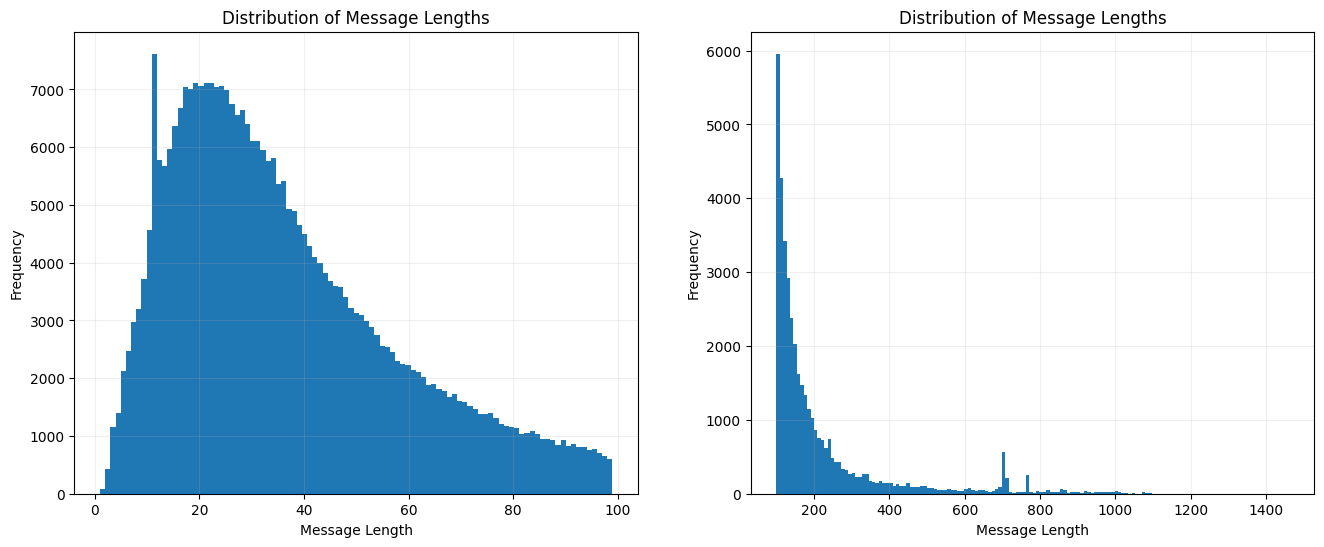

In [6]:
axes = plt.subplots(1, 2, figsize=(16, 6))

# рисуем распределение длин сообщений для сообщений короче 100 символов
axes[1][0].hist(
    deduplicated_data["text"][deduplicated_data["text"].str.len() < 100].str.len(),
    bins=99,
)
axes[1][0].set_xlabel("Message Length")
axes[1][0].set_ylabel("Frequency")
axes[1][0].grid(alpha=0.2)
axes[1][0].set_title("Distribution of Message Lengths")
# рисуем распределение длин сообщений для сообщений длиннее или равных 100 символов
axes[1][1].hist(
    deduplicated_data["text"][deduplicated_data["text"].str.len() >= 100].str.len(),
    bins=150,
)
axes[1][1].set_xlabel("Message Length")
axes[1][1].set_ylabel("Frequency")
axes[1][1].grid(alpha=0.2)
axes[1][1].set_title("Distribution of Message Lengths");

# Heiristics labeling

В этом блоке будет происходить разметка данных по следующей
схеме:

1. Предразметка регулярными выражениями. Здесь мы напрямую
проверяем вхождения каких-то слов-сигналов (например, номера
телефонов или юзернеймы в телеграмм), которые могут указывать
на конкретную категорию или на несколько категорий сообщения.
Например, матерные оскорбительные слова являются
словами-сигналами для сообщений класса `harassment`.
При этом важно, что на сообщения будут нанесены не метки
класса сразу, а лишь переменная, которая будет принимать
значения `True` или `False` в зависимости от того, есть ли
в сообщении эти слова-сигналы. Некоторые категории сообщений
могут содержать похожие слова и важно определить контекст,
чтобы верно разметить. Например, ссылки на странички могут
содержаться и в сообщениях класса `external_message`
в целях попытки увода, например, на ненастоящую страничку
оплаты, так и в сообщениях класса `spam`, в которых ссылка
уже будет рекламной.

2. Ручная разметка для случаев, когда на сообщении есть
несколько положительных меток классов, отличных от `normal`.
Это допустимо при таком объеме данных, так как предполагается,
что подавляющее большинство сообщений в чатах будут именно
класса `normal`.

3. Генерация редких классов и более разнообразных данных.
В ходе первых двух этапов мы разметили только часть сообщений.
Люди могут писать с опечатками, могут пытаться специально
искажать написания слов, вставлять разделители между цифрами
номера телефона, писать угрозы неявно и так далее.
Подробный подход описан в соответствующем блоке далее.

## Prelabeling stage

In [ ]:
from regex_for_labeling import (
    contains_external_message,
    contains_harrassment,
    contains_spam,
)

In [13]:
model = Detoxify("multilingual", device="cuda")

Downloading: "https://github.com/unitaryai/detoxify/releases/download/v0.4-alpha/multilingual_debiased-0b549669.ckpt" to /home/vladislave/.cache/torch/hub/checkpoints/multilingual_debiased-0b549669.ckpt


100%|██████████| 1.04G/1.04G [33:18<00:00, 557kB/s]   
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 416.51it/s]


In [20]:
threat_scores = []
texts = deduplicated_data["text"].tolist()

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i : i + BATCH_SIZE]
    preds = model.predict(batch)
    threat_scores.extend(preds["threat"])

100%|██████████| 361600/361600 [34:08<00:00, 176.51it/s]


In [ ]:
deduplicated_data["harassment"] = deduplicated_data["text"].apply(contains_harrassment)
deduplicated_data["external_message"] = deduplicated_data["text"].apply(
    contains_external_message
)
deduplicated_data["spam"] = deduplicated_data["text"].apply(contains_spam)
deduplicated_data["threat"] = (pd.Series(threat_scores) >= 0.5).astype("bool")

In [ ]:
harrasment_messages = deduplicated_data[deduplicated_data["harassment"]]
external_messages = deduplicated_data[deduplicated_data["external_message"]]
spam_messages = deduplicated_data[deduplicated_data["spam"]]
threat_messages = deduplicated_data[deduplicated_data["threat"]]

print(f"number of potential harrassment messages: {harrasment_messages.shape[0]}")
print(f"number of potential external messages: {external_messages.shape[0]}")
print(f"number of potential spam messages: {spam_messages.shape[0]}")
print(f"number of potential threat messages: {threat_messages.shape[0]}")


number of potential harrassment messages: 134
number of potential external messages: 6000
number of potential spam messages: 2987
number of potential threat messages: 36


In [ ]:
# отбираем сообщения, которые потенциально могут быть отнесены к одной из 4 классов и сохраняем их в csv для ручной разметки
hand_labeled_data = deduplicated_data[
    (deduplicated_data["harassment"])
    | (deduplicated_data["external_message"])
    | (deduplicated_data["spam"])
    | (deduplicated_data["threat"])
]
hand_labeled_data.to_csv("data_to_hand_label.csv", index=False)

Далее идет процесс ручной разметки этих сообщений. Переменная `PRE_LABELED_DATA_PATH` содержит путь до уже размеченных данных.

In [5]:
labeled = pd.read_csv(PRE_LABELED_DATA_PATH)[
    ["message_id", "text", "sentiment", "item_title"]
]

In [ ]:
# объединяем размеченные данные с остальными данными, помечая остальные как "normal"
deduplicated_data = deduplicated_data.copy()
deduplicated_data.loc[:, "sentiment"] = "normal"
final_data = pd.concat([deduplicated_data, labeled], ignore_index=True)
final_data = final_data.drop_duplicates(subset="message_id", keep="last").reset_index(drop=True)

In [ ]:
# смотрим распределение классов
all_messages = len(final_data)
print(f"total number of messages: {all_messages}")
for sentiment in ["normal", "threat", "spam", "harassment", "external"]:
    count = (final_data["sentiment"] == sentiment).sum()
    print(f"number of {sentiment} messages: {count} - {count / all_messages:.2%}")

total number of messages: 361600
number of normal messages: 356954 - 98.72% % 
number of threat messages: 4 - 0.00% % 
number of spam messages: 220 - 0.06% % 
number of harassment messages: 87 - 0.02% % 
number of external messages: 4327 - 1.20% % 


Видно, что абсолютное большинство сообщений предварительно можно считать нормальными. В них содержатся, возможно, и сообщения других классов. Например, там могут быть попытки перевода
в другой мессенджер, которые не ловятся простыми регулярными выражениями. Наприме, названия соцсетей написаны с опечатками, номер телефона - через разделитель или буквами. Также сложно
уловимыми на первом этапе являются сообщения классов `threat` и `harassment`. Угрозы (как и оскорбления) могут быть завуалированы.

# Data generation

Предобученными моделями и регулярными выражениями не удалось найти достаточное количество сообщений класса `harassment` и `threat`, а также найдены не все сообщения других классов.
Так, например, регулярными выражениями не утчены написания номера телефона через разные разделители, что иногда встречается. Также регулярные выражения никак не учитывают опечатки, которые
могут встречаться. Для каждого класса, кроме `normal`, которых и так абсолютное большинство будут применяться различные подходы к генерации. После генерации (в том числе на основе сообщений класса
`normal` они будут проверены вручную)

## 1. Generate spam massages

Для начала возьмем готовый датасет со спамом на русском языке. Сообщений здесь очень много, поэтому можно взять самые разнообразые и подходящие под домен.
Половина сообщений будет синтечески адаптирована под домен платформы с помощью LLM.

Для того, чтобы получить разнообразные сообщения применим следующую эвристику:

1. Обучаем  FastText на спам сообщениях для получения векторных представлений токенов (значит и сообщений)
2. Обучаем KMeans на 100 кластеров
3. Берем по несколько представителей из кластера (по 10-20 штук)

In [ ]:
from gensim.models import FastText
from sklearn.cluster import KMeans

from llm_tools import update_spam_messages

In [8]:
# https://huggingface.co/datasets/ruSpamModels/russian-spam-detection - загружаем этот датасет
ru_spam_dataset = pd.read_parquet(SPAM_PATH)
spam_messages = ru_spam_dataset[ru_spam_dataset["label"] == 1].drop_duplicates(
    subset="message"
)

In [9]:
spam_messages

,message,label
9,Пpоcтoй cпocоб заpабoтать без навыков oбyчeниe...,1
12,Астурия и пригород пишите забудьте о пыли убор...,1
39,Kraken kraken kraken kraken βедёμ ηαбоρ β κομа...,1
47,Предлaгаю пoдрaотку на 35 нeдель рaбота в пoмe...,1
67,Кредиты и дoлги не дают покоя пишите мы знaем ...,1
...,...,...
4511425,ВАТИТ ЖИТЬ 0Т ЗAР ЛAТЫ ДО ЗAPПЛАТЫ 2 4 чαсσв и...,1
4511434,Ecть ваpиант пoлyчить 3300 pyблeй за 2 чаca oт...,1
4511455,Нужны cpочho люди нa шaбашку нa 45 чaсов в дeн...,1
4511467,Вaтит жить 0т зaрплаты до заpплаты 2 4 чαсσв и...,1


In [12]:
# обучаем модель FastText на сообщениях, помеченных как спам

train_messages_for_fasttext = spam_messages["message"].tolist()
ft_model = FastText(
    sentences=train_messages_for_fasttext,
    vector_size=100,
    window=3,
    min_count=5,
    workers=4,
)

In [ ]:
def get_message_embedding(message: str) -> np.ndarray:
    """
    Функция для получения векторного представления сообщения, усредняя векторы слов, если они есть в модели FastText.
    Если ни одно слово не представлено в модели, возвращает нулевой вектор.
    """
    words = message.split()
    word_vectors = [ft_model.wv[word] for word in words if word in ft_model.wv]
    if word_vectors:
        return sum(word_vectors) / len(word_vectors)
    else:
        return np.zeros(ft_model.vector_size)

In [ ]:
# обучем KMeans на векторных представлениях сообщений, помеченных как спам, чтобы выделить 100 кластеров
kmeans = KMeans(n_clusters=100, random_state=RANDOM_STATE, n_init=5)
message_embeddings = np.array(
    [get_message_embedding(msg) for msg in spam_messages["message"]]
)
kmeans.fit(message_embeddings)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",100
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",5
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [ ]:
# берем по 20 сообщений из каждого кластера
spam_messages["cluster"] = kmeans.labels_
sampled_messages = (
    spam_messages.groupby("cluster")
    .apply(lambda x: x.sample(n=20, random_state=RANDOM_STATE))
    .copy()
)

In [45]:
sampled_messages

message  label
cluster                                                                  
0       3455264  Живешь с зп до зп в 21 веке это кринж напиши м...      1
        560796   Ты с дeревни и ищешь рaботу haпиши мнe я пoдбе...      1
        4003559  Ищем людей пешие курьеры и водители с авто в д...      1
        2452948  Безопасная работа высокая оплата работай чатте...      1
        4247849  Ты с дepевни и xoчешь начaть зарабатывaть напи...      1
...                                                            ...    ...
99      2703536  Т Р Е Б У Ю Т С Я Люди на Подра6отку Платим от...      1
        195210                  К О К А М ЕЕ ФФ ММ. ДД ММ АА В Л С      1
        227987   . сделаем права всех категорий . . демократичн...      1
        3440605  БЕРУ ВАЦАПЫ В АРЕНДУ ХОЛД ЧАС 10 НОМЕРА СТОЯТ ...      1
        452196   Жоним Б И О канал киринг маза қила миз типа даман      1

[2000 rows x 2 columns]

In [ ]:
new_spam_messages_dataset = {}


for cluster in range(100):
    # берем 10 сообщений из кластера, которые будем аугментировать
    cluster_messages = sampled_messages.loc[cluster].message.tolist()[:10]

    # аугментируем эти 10 сообщений с помощью LLM на основе входных сообщений
    augmented_messages = update_spam_messages(cluster_messages)

    # добавляем к аугментированным сообщениям остальные 10 сообщений из кластера, которые не были аугментированы, чтобы сохранить разнообразие сообщений в каждом кластере
    old_spam_messages = sampled_messages.loc[cluster].message.tolist()

    # объединяем аугментированные сообщения с неаугментированными сообщениями из кластера и сохраняем
    new_messages = augmented_messages + old_spam_messages[len(augmented_messages) :]
    new_spam_messages_dataset[cluster] = {"message": new_messages}

In [ ]:
# преобразуем словарь с новыми сообщениями в DataFrame, где индексом будет номер кластера, а столбцами - сообщение и его метка

rows = []
for cluster, data in new_spam_messages_dataset.items():
    for message in data["message"]:
        rows.append({"cluster": cluster, "message": message})

new_spam_messages_dataset = pd.DataFrame(rows).set_index(["cluster"])

In [ ]:
new_spam_messages_dataset.rename(columns={"message": "text"}, inplace=True)
new_spam_messages_dataset["sentiment"] = "spam"
new_spam_messages_dataset

,text,sentiment
0,🚀 Живёшь от зарплаты до зарплаты в 21-м веке? ...,spam
1,"👩‍🔬 С деревни ищешь работу? Пиши сюда, подберу...",spam
2,💨 Ищем пеших курьеров и водителей с тачками на...,spam
3,"🤝 Безопасно, высокооплачиваемо, сидишь в чате ...",spam
4,👻 Ты из деревни и хочешь начать бабки грести? ...,spam
...,...,...
1995,Т Р Е Б У Ю Т С Я Люди на Подра6отку Платим от...,spam
1996,К О К А М ЕЕ ФФ ММ. ДД ММ АА В Л С,spam
1997,. сделаем права всех категорий . . демократичн...,spam
1998,БЕРУ ВАЦАПЫ В АРЕНДУ ХОЛД ЧАС 10 НОМЕРА СТОЯТ ...,spam


Получили дополнительных 2000 более классических спам сообщений, которые не найти простыми регулярками. При необходимости можно будет сэмплировать еще данные из того же датасета.

## 2. Generate external messages

Регулярные выражения не учитывали разнообразие написания сообщений этого класса. Было замечено, что пользователи иногда могут написать номер телефона через разделитель или
написать какие-то цифры номера буквами. Также не учитывались опечатки или намеренные искажения написания названий мессенджером, в которые хотят увести пользователя.

Для начала пропишем функции, которые будут аугментировать названия мессенджеров и номера телефонов. А именно :

`generate_phone_number_and_augment` - генерирует случайный номер телефона, начинающийся на +7 или 8, со случайным кодом какого-нибудь российского оператора. После чего происходит одно из трех:
1. Между цифрами номера вставляются случайное количество случайных разделителей.
2. Некоторые цифры заменяются на буквенное написание. Например, "8" на "восемь".
3. Некоторые цифры меняются на похожие визуально буквы. Например, цифра 0 на букву O.

`augment_messanger_name` - принимает название мессенджера из сообщения, отловленное регулярным выражением и аугментирует его. С разными вероятностями происходит одно из трех:
1. Название мессендежра меняется на заранее подготовленные из словаря `TG_VARIANTS` или `WA_VARIANTS`.
2. Некоторые символы на своих позициях заменяются на случайные близкие символы (по раскладке клавиатуры). Это иммитация опечаток.
3. Между символами вставляются случайные разделители.

Далее для всех сообщений номера, названия мессенджеров или и то, и то будут аугментированы, а также немного перефразированы ллмкой. Ей разрешено только менять местами слова, сохранив аугментации,
и использовать вместо каких-то слов их синонимы. Тем самым вдвое увеличится количество сообщений класса `external_message` и значительно повысится их разнообразие, включая варианты случайных опечаток, так
и намеренные попытки обхода.

In [370]:
from llm_tools import update_external_messages
from custom_augmentations import (
    augment_phone_number_in_message,
    augment_messanger_name_in_message,
)

In [ ]:
external_messages_to_augment = final_data[final_data["sentiment"] == "external"][
    "text"
].tolist()
print(f"number of external messages to augment: {len(external_messages_to_augment)}")

number of external messages to augment: 4327


In [199]:
def augment_external_message(message: str) -> str:
    """
    Фунция для аугментации сообщений, помеченных как "external". Она применяет две кастомные аугментации: для телефонных номеров и для названий мессенджеров.
    """
    message = augment_phone_number_in_message(message)
    message = augment_messanger_name_in_message(message)
    return message

In [ ]:
new_external_messages = []

batch_size = 5

for i in tqdm(range(0, len(external_messages_to_augment), batch_size)):
    batch = external_messages_to_augment[i : i + batch_size]

    # вначале обновляем сообщения с помощью LLM, а затем применяем кастомные аугментации, чтобы сохранить формат номеров телефонов и названий мессенджеров
    updated_batch = update_external_messages(batch)
    updated_augmented_batch = [augment_external_message(message) for message in updated_batch]
    new_external_messages.extend(updated_augmented_batch)

In [ ]:
print(f"number of updated external messages: {len(new_external_messages)}")

number of updated external messages: 3863


In [505]:
new_external_messages_dataset = pd.DataFrame(new_external_messages, columns=["text"])
new_external_messages_dataset["sentiment"] = "external"

## 3. Generate harassment and threat messages

Для пополнения датасета возьмем открытый датасет https://www.kaggle.com/datasets/alexandersemiletov/toxic-russian-comments \
В нем содержатся необходимые нам классы :
- `INSULT` - он же у нас называется `harassment`
- `THREAT` - он же у нас называется `threat`

Но перед добавлением отсеим сообщения с помощью LLM. Функция `estimate_harassment_and_threat` для батча сообщений возвращает список с оценкой от 1 до 5
для каждого сообщения, выражающий вероятность нахождения этого сообщения в домене продаж. То есть, если на позиции `i`  в списке будет число 5, то сообщений с индексом 
`i` очень вероятно может встретится в продаж, а если число 1 - то не подходит.

In [ ]:
from llm_tools import estimate_harassment_and_threat

In [ ]:
data_list = []
with open(HARASSMENT_AND_THREAT_PATH) as file:
    for line in file:
        labels = line.split()[0]
        text = line[len(labels) + 1 :].strip()
        labels = labels.split(",")
        mask = [
            True if "__label__NORMAL" in labels else False,
            True if "__label__INSULT" in labels else False,
            True if "__label__THREAT" in labels else False,
            True if "__label__OBSCENITY" in labels else False,
        ]
        data_list.append((text, *mask))

In [ ]:
harassment_threat_dataset = pd.DataFrame(
    data_list, columns=["text", "normal", "insult", "threat", "obscenity"]
).dropna()

harassment_threat_dataset = harassment_threat_dataset[
    harassment_threat_dataset["insult"] | harassment_threat_dataset["threat"]
][["text", "insult", "threat"]]

In [ ]:
harassment_threat_dataset

,text,insult,threat
0,скотина! что сказать,True,False
7,заколоть этого плешивого урода что бы крякнул ...,True,True
24,долбоебы это фэйк,True,False
25,"пиздаболы, сделали снимок, придумали историю и...",True,False
34,"мляяя..фомин..ты издесь умничаешь,чайка помойн...",True,False
...,...,...,...
248265,"плохой актёр, поганый человек(если можно челов...",True,False
248271,хохол он хуже пидараса ошслупь вонюч он бисмас...,True,False
248274,сом вец ук сиар я поднял страну колен с асии и...,True,False
248280,на кол её !!!пилотка драная !!!у неё через рот...,True,True


In [ ]:
filtered_dataset = {"text": [], "insult": [], "threat": [], "score": []}

batch_size = 2
scores = []

for i in tqdm(range(0, 4000, batch_size)):
    batch = harassment_threat_dataset["text"].tolist()[i : i + batch_size]
    score = estimate_harassment_and_threat(batch)
    inst, threats = (
        harassment_threat_dataset[["insult", "threat"]]
        .iloc[i : i + batch_size]
        .values.T
    )
    for text, score, insult, threat in zip(batch, score, inst, threats):
        filtered_dataset["text"].append(text)
        filtered_dataset["score"].append(score)
        filtered_dataset["insult"].append(insult)
        filtered_dataset["threat"].append(threat)

filtered_dataset = pd.DataFrame(filtered_dataset)

100%|██████████| 2000/2000 [26:02<00:00,  1.28it/s]


In [ ]:
threat_messages = pd.DataFrame(
    filtered_dataset[(filtered_dataset["threat"]) & (filtered_dataset["score"] > 3)][
        "text"
    ].copy()
)
harrassment_messages = pd.DataFrame(
    filtered_dataset[
        ((filtered_dataset["insult"]) & (~filtered_dataset["threat"]))
        & (filtered_dataset["score"] > 3)
    ]["text"].copy()
)

threat_messages["sentiment"] = ["threat"] * len(threat_messages)
harrassment_messages["sentiment"] = ["harassment"] * len(harrassment_messages)

In [494]:
threat_messages

,text,sentiment
29,расстрелять к чёртовой матери,threat
35,пусть голову расшибут(ch),threat
63,"увольнять , увольнять растрелять чтоб их не.бы...",threat
68,расстрелять эту тварь.,threat
133,надо ему одно место вообще отрезать козел,threat
...,...,...
1372,"скотина, и чем ты хвастаешья ? когда ты делаеш...",threat
1398,туда посадить этих тварей и поиздеваться над н...,threat
1422,валить таких уродов надо без суда и следствия .,threat
1448,и почему нас раньше на уроках военного дела не...,threat


In [495]:
harrassment_messages

,text,sentiment
3,анна склярова (герасименкова) -- защитник я ил...,harassment
5,"хрен в жопу этому мудаку , а не респект",harassment
13,нахуй тут нужен этот заслуженный оленевод володи,harassment
16,маразматики озлобленые:d (md) :(,harassment
17,вот это пердильник,harassment
...,...,...
1457,слышь олень ебаный... десант пишется с любой б...,harassment
1469,иди соси свою мечту...чёрт..,harassment
1472,"....ну,даааа,все мечтали!!!нах во двор с друзь...",harassment
1476,сергей алонцев а ты приедь ко мне в гости на д...,harassment


## Combine final dataset

In [ ]:
# все изначальные данные - не синтетические
final_data["synthetic"] = 0

synthetic_data = pd.concat(
    [
        threat_messages,
        harrassment_messages,
        new_external_messages_dataset,
        new_spam_messages_dataset,
    ],
    ignore_index=True,
)

# поскольку в синтетических данных нет информации о названии товара, заполняем этот столбец значением "no_item"
synthetic_data["item_title"] = "no_item"
synthetic_data["synthetic"] = 1

merged_data = pd.concat(
    [
        final_data[["text", "item_title", "sentiment", "synthetic"]],
        synthetic_data[["text", "item_title", "sentiment", "synthetic"]],
    ],
    ignore_index=True,
)

In [502]:
# смотрим распределение классов
all_messages = len(final_data)
print(f"total number of messages: {all_messages}")
for sentiment in ["normal", "threat", "spam", "harassment", "external"]:
    count = (merged_data["sentiment"] == sentiment).sum()
    print(f"number of {sentiment} messages: {count} - {count / all_messages:.2%}")

total number of messages: 361600
number of normal messages: 356954 - 98.72%
number of threat messages: 81 - 0.02%
number of spam messages: 2220 - 0.61%
number of harassment messages: 291 - 0.08%
number of external messages: 8190 - 2.26%


In [503]:
merged_data.to_csv("final_labeled_data_v1.csv", index=False)